In [7]:
import os

os.chdir("/Users/yseeparenti/icloud/TSP/2A/NET4103/") 

print("Nouveau dossier de travail :", os.getcwd())
print("Fichiers/Dossiers présents ici :", os.listdir())


Nouveau dossier de travail : /Users/yseeparenti/Library/Mobile Documents/com~apple~CloudDocs/TSP/2A/NET4103
Fichiers/Dossiers présents ici : ['Homework_NET4103.ipynb', '.DS_Store', '.gitignore', 'devoir_net4103.py', '.git', 'data']


## Question 2 : Social Network Analysis


--- Analyse de Caltech ---
Densité: 0.0574
Clustering global: 0.2913
Clustering local moyen: 0.4091


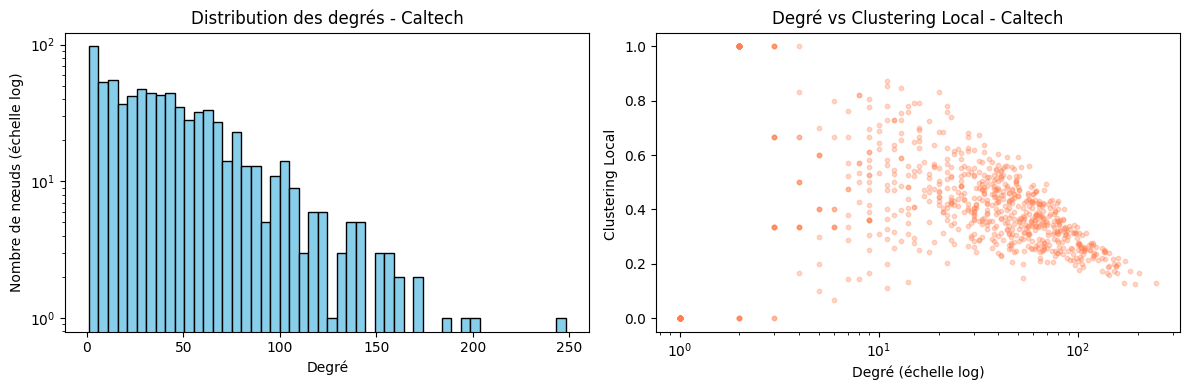


--- Analyse de MIT ---
Densité: 0.0123
Clustering global: 0.1803
Clustering local moyen: 0.2724


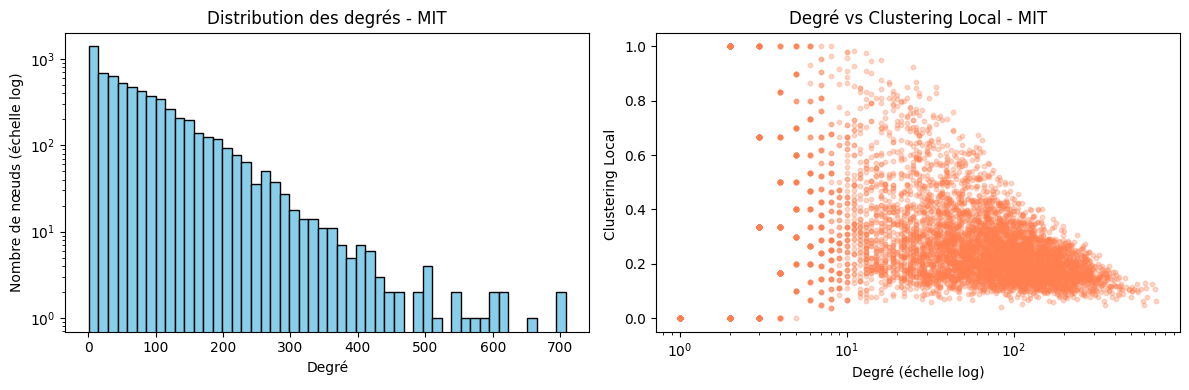


--- Analyse de Johns Hopkins ---
Densité: 0.0140
Clustering global: 0.1932
Clustering local moyen: 0.2690


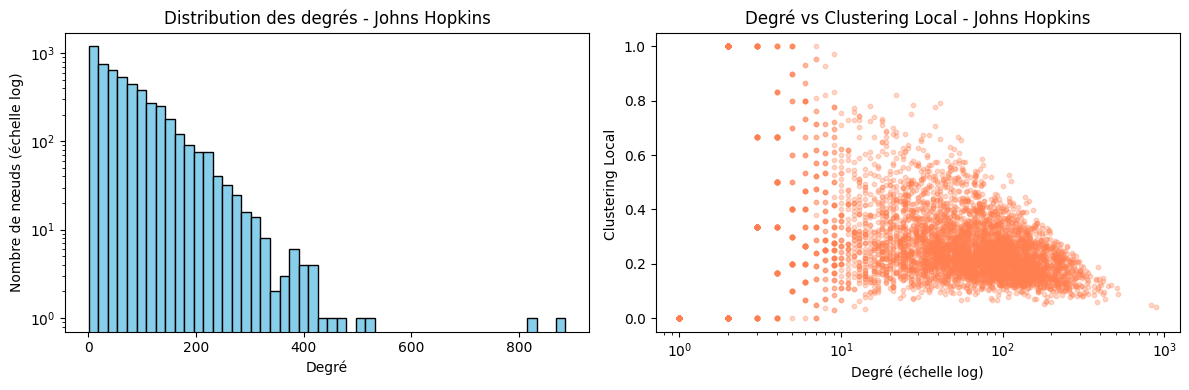

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Charger les données 
graphes = {
    "Caltech": nx.read_gml("data/Caltech36.gml"),
    "MIT": nx.read_gml("data/MIT8.gml"),
    "Johns Hopkins": nx.read_gml("data/JohnsHopkins55.gml")
}

for nom, G in graphes.items():
    composantes = nx.connected_components(G)
    lcc_nodes = max(composantes, key=len)
    G = G.subgraph(lcc_nodes)
    print(f"\n--- Analyse de {nom} ---")
    
    # a) Calculs
    densite = nx.density(G)
    clustering_global = nx.transitivity(G)
    clustering_local_moyen = nx.average_clustering(G)
    
    print(f"Densité: {densite:.4f}")
    print(f"Clustering global: {clustering_global:.4f}")
    print(f"Clustering local moyen: {clustering_local_moyen:.4f}")
    
    # Distribution des degrés
    degres = [deg for node, deg in G.degree()]
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(degres, bins=50, color='skyblue', edgecolor='black', log=True)
    plt.title(f"Distribution des degrés - {nom}")
    plt.xlabel("Degré")
    plt.ylabel("Nombre de nœuds (échelle log)")
    
    # b) Scatter plot Degré vs Clustering Local
    clustering_local = nx.clustering(G)
    plt.subplot(1, 2, 2)
    plt.scatter(degres, list(clustering_local.values()), alpha=0.3, s=10, color='coral')
    plt.xscale('log')
    plt.title(f"Degré vs Clustering Local - {nom}")
    plt.xlabel("Degré (échelle log)")
    plt.ylabel("Clustering Local ")
    
    plt.tight_layout()
    plt.show()

## Question 3 : Assortativity Analysis

In [ ]:
'''''
import os
import networkx as nx
import matplotlib.pyplot as plt

dossier_data = "data" 

attributs = ["student_fac", "major_index", "dorm", "gender", "degree"]

resultats_assortativite = {attr: [] for attr in attributs}
tailles_reseaux = []

fichiers_gml = [f for f in os.listdir(dossier_data) if f.endswith('.gml')]
print(f"Début de l'analyse sur {len(fichiers_gml)} graphes. Ça va prendre du temps, va prendre un café ! ☕\n")

# Boucle sur les 100 graphes
for index, fichier in enumerate(fichiers_gml):
    chemin_fichier = os.path.join(dossier_data, fichier)
    G = nx.read_gml(chemin_fichier)
    
    # 1. Enregistrer la taille du réseau (n)
    n = G.number_of_nodes()
    tailles_reseaux.append(n)
    
    # 2. Nettoyage des données : attribuer 0 si un attribut est manquant pour un nœud
    for node, data in G.nodes(data=True):
        for attr in attributs:
            if attr != "degree" and attr not in data:
                data[attr] = 0
                
    # 3. Calculs des assortativités
    for attr in attributs:
        try:
            if attr == "degree":
                r = nx.degree_assortativity_coefficient(G)
            else:
                r = nx.attribute_assortativity_coefficient(G, attr)
            resultats_assortativite[attr].append(r)
        except Exception as e:
            import numpy as np
            resultats_assortativite[attr].append(np.nan)
            
    # Affichage de la progression tous les 10 graphes
    if (index + 1) % 10 == 0:
        print(f"Progression : {index + 1} / {len(fichiers_gml)} graphes traités...")

print("\nCalculs terminés ! Génération des graphiques...")

# Génération graphs
for attr in attributs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Analyse de l'Assortativité : {attr.upper()}", fontsize=16)
    
    donnees_y = resultats_assortativite[attr]
    
    # 1. Scatter Plot (Assortativité vs Taille du réseau)
    ax1 = axes[0]
    ax1.scatter(tailles_reseaux, donnees_y, alpha=0.7, color='steelblue', edgecolors='black')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1.5) # Ligne indiquant aucune assortativité
    ax1.set_xscale('log') # Axes log-linéaires demandés
    ax1.set_xlabel('Taille du réseau (n) - Échelle Log')
    ax1.set_ylabel(f'Assortativité ({attr})')
    ax1.set_title(f'{attr} vs Taille du réseau')
    ax1.set_ylim([-0.2, max(donnees_y) + 0.1 if max(donnees_y) == max(donnees_y) else 0.5])
    
    # 2. Histogramme (Distribution des valeurs)
    ax2 = axes[1]
    donnees_propres = [val for val in donnees_y if str(val) != 'nan']
    ax2.hist(donnees_propres, bins=20, color='lightcoral', edgecolor='black')
    ax2.axvline(0, color='black', linestyle='--', linewidth=1.5) 
    ax2.set_xlabel(f'Assortativité ({attr})')
    ax2.set_ylabel('Fréquence (Nombre de réseaux)')
    ax2.set_title(f'Distribution de l\'assortativité ({attr})')
    ax2.set_xlim([-0.2, 0.5]) 
    
    plt.tight_layout()
    plt.show()

## Question 4 : Link Prediction

In [ ]:
import networkx as nx
import random
import math
from abc import ABC, abstractmethod

G = nx.read_gml("data/Caltech36.gml")
G_lcc = G.subgraph(max(nx.connected_components(G), key=len))


#PARTIE 4(b) : LES CLASSES DE PRÉDICTION 
class LinkPrediction(ABC):
    def __init__(self, graph):
        self.graph = graph
        self.N = len(graph)
        
    def neighbors(self, v):
        return list(self.graph.neighbors(v))
        
    @abstractmethod
    def fit(self, u, v):
        raise NotImplementedError("Fit must be implemented")

class CommonNeighbors(LinkPrediction):
    def fit(self, u, v):
        return len(set(self.neighbors(u)).intersection(set(self.neighbors(v))))

class Jaccard(LinkPrediction):
    def fit(self, u, v):
        nu = set(self.neighbors(u))
        nv = set(self.neighbors(v))
        union_size = len(nu.union(nv))
        if union_size == 0: return 0
        return len(nu.intersection(nv)) / union_size

class AdamicAdar(LinkPrediction):
    def fit(self, u, v):
        common = set(self.neighbors(u)).intersection(set(self.neighbors(v)))
        return sum(1.0 / math.log(self.graph.degree(w)) for w in common if self.graph.degree(w) > 1)


# PARTIE 4(c) : LE PIPELINE D'ÉVALUATION 
def evaluate_predictor(G, predictor_class, f=0.1, k_values=[50, 100, 200, 300, 400]):
    print(f"Évaluation de {predictor_class.__name__} (fraction retirée f={f})...")
    
    # Étape 1 & 2 : Retirer une fraction f d'arêtes aléatoirement
    edges = list(G.edges())
    num_to_remove = int(f * len(edges))
    edges_removed = set(random.sample(edges, num_to_remove))
    
    # Création du graphe d'entraînement (sans les arêtes retirées)
    G_train = G.copy()
    G_train.remove_edges_from(edges_removed)
    
    # Étape 3 : Calculer le score pour toutes les paires de nœuds non connectées dans G_train
    predictor = predictor_class(G_train)
    predictions = []
    
    for u, v in nx.non_edges(G_train):
        score = predictor.fit(u, v)
        if score > 0: 
            predictions.append((score, frozenset([u, v])))
            
    # Étape 4 : Trier par ordre décroissant de confiance
    predictions.sort(key=lambda x: x[0], reverse=True)
    
    
    E_removed_set = set(frozenset([u, v]) for u, v in edges_removed)
    
    results = {}
    # Étape 5 : Calcul des métriques pour chaque k
    for k in k_values:
        
        top_k_preds = set(pair for score, pair in predictions[:k])
        
        
        TP = len(E_removed_set.intersection(top_k_preds))
        FP = k - TP
        FN = len(E_removed_set) - TP
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        results[k] = {'Precision': precision, 'Recall': recall}
        
    return results

# PARTIE 4(d) : EXÉCUTION 
predictors = [CommonNeighbors, Jaccard, AdamicAdar]

for pred in predictors:
    res = evaluate_predictor(G_lcc, pred, f=0.1)
    print(f"Résultats pour {pred.__name__}:")
    for k, metrics in res.items():
        print(f"  k={k} -> Precision: {metrics['Precision']:.4f} | Recall: {metrics['Recall']:.4f}")
    print("-" * 30)